## COMPAS - 3 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals and Regularization coefficient

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import LogRegScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [5]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

In [6]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10000

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [7]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 3
results = {}

In [8]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(num_objs=3,
                            X=X_train, 
                            y=y_train, 
                            fair_feat=fair_feature,
                            #tol=tol, max_iter=max_iter
                            )
equal.optimize(np.array([1/3, 1/3, 1/3]))

## MOLA

22:31:04 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:31:04 | DEBUG | machinemoo | Finding 1th individual minimum
22:31:04 | DEBUG | machinemoo | Finding 2th individual minimum
22:31:04 | DEBUG | machinemoo | Finding 3th individual minimum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:452: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/workspace/ma

new solution added [0.61523737 0.61798065 0.79301504]


22:31:04 | DEBUG | machinemoo | Calculated weights: [0.99268753 0.         0.00731247]
22:31:04 | DEBUG | machinemoo | Importance: 0.0008288751725503696
22:31:04 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.79301504]
22:31:04 | DEBUG | machinemoo | Iteration 2
22:31:04 | DEBUG | machinemoo | Solutions list: [array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


new solution added [0.61294861 0.61946406 0.8736994 ]


22:31:05 | DEBUG | machinemoo | Calculated weights: [0.97241568 0.         0.02758432]
22:31:05 | DEBUG | machinemoo | Importance: 0.0008119485637896329
22:31:05 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.79301504]
22:31:05 | DEBUG | machinemoo | Iteration 3
22:31:05 | DEBUG | machinemoo | Solutions list: [array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


...

22:31:15 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
22:31:15 | DEBUG | machinemoo | Importance: 0.0035365367306303686
22:31:15 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
22:31:15 | DEBUG | machinemoo | Iteration 148
22:31:15 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402,

new solution dominated [0.62168929 0.62981861 0.22138124]


22:31:15 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
22:31:15 | DEBUG | machinemoo | Importance: 0.0035365367306303686
22:31:15 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
22:31:15 | DEBUG | machinemoo | Iteration 149
22:31:15 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402,

new solution dominated [0.62168929 0.62981861 0.22138124]


22:31:15 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
22:31:15 | DEBUG | machinemoo | Importance: 0.0035365367306303686
22:31:15 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
22:31:15 | DEBUG | machinemoo | Iteration 150
22:31:15 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402,

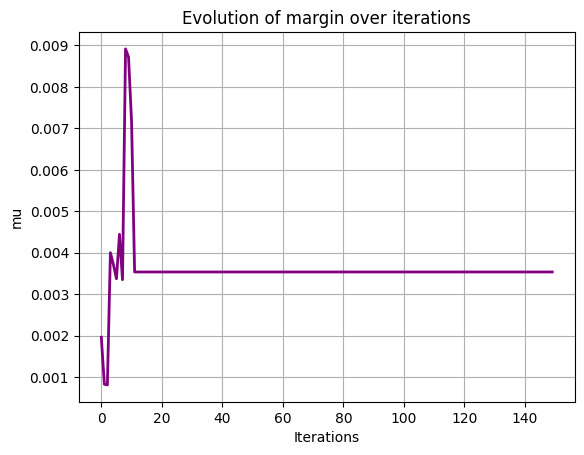

22:31:15 | INFO | machinemoo | Fit runtime: 10.91 seconds


In [9]:
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

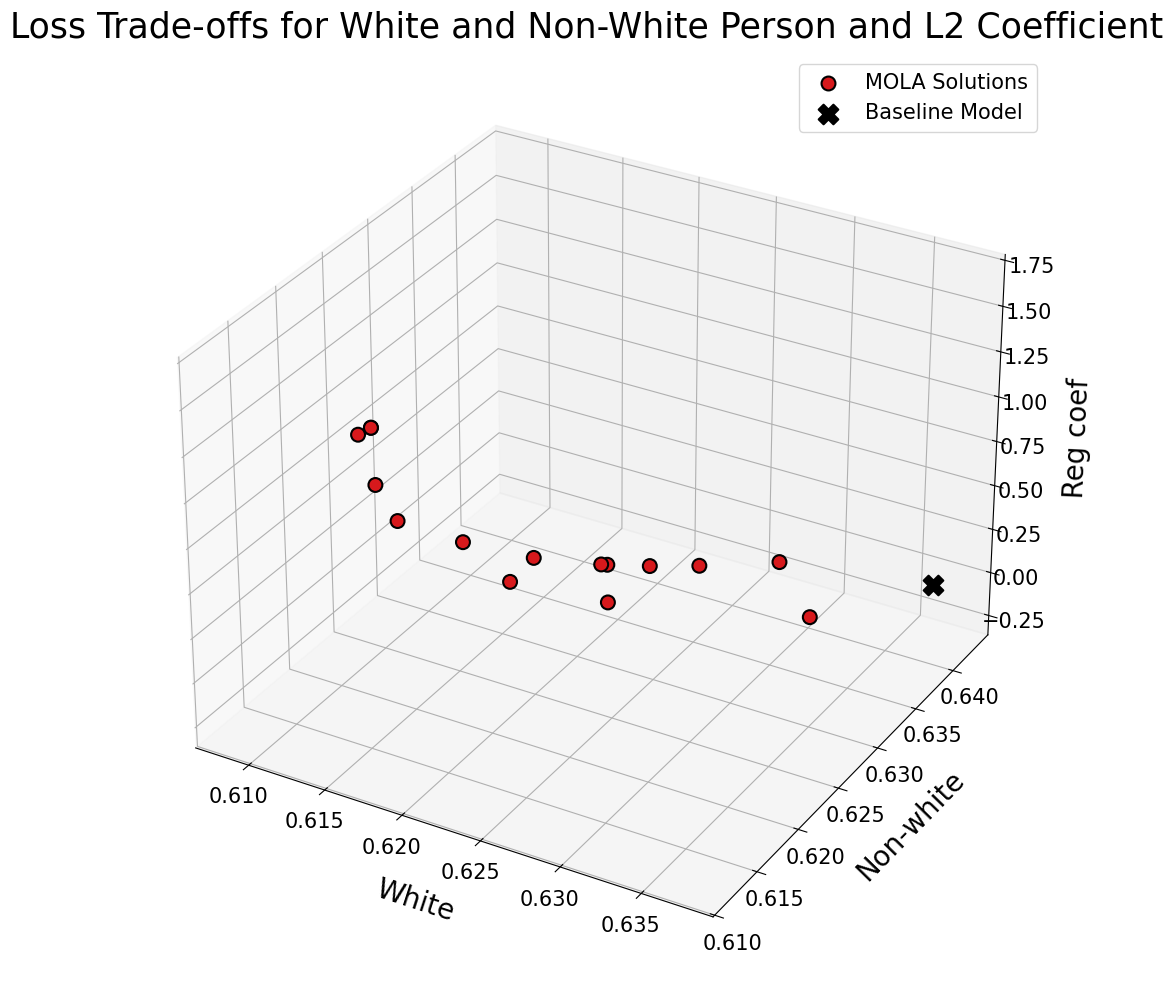

In [10]:
title = title="Loss Trade-offs for White and Non-White Person and L2 Coefficient"
plot_pareto(methods={'mola': objs},
            labels=("White", "Non-White", "Reg Coef"), 
            title=title,
            point = equal.objs,
            save_path='images/3_objs_mola.png',
            figsize=(10,10),
            fontsize=20,
            s_factor=2
            )

22:33:50 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:33:50 | DEBUG | machinemoo | Finding 1th individual minimum
22:33:50 | DEBUG | machinemoo | Finding 2th individual minimum
22:33:50 | DEBUG | machinemoo | Finding 3th individual minimum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:452: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/workspace/ma

new solution added [0.61523737 0.61798065 0.79301504]


22:33:50 | DEBUG | machinemoo | Calculated weights: [0.99268753 0.         0.00731247]
22:33:50 | DEBUG | machinemoo | Importance: 0.0008288751725503696
22:33:50 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.79301504]
22:33:50 | DEBUG | machinemoo | Iteration 2
22:33:50 | DEBUG | machinemoo | Solutions list: [array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


new solution added [0.61294861 0.61946406 0.8736994 ]


22:33:50 | DEBUG | machinemoo | Calculated weights: [0.97241568 0.         0.02758432]
22:33:50 | DEBUG | machinemoo | Importance: 0.0008119485637896329
22:33:50 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.79301504]
22:33:50 | DEBUG | machinemoo | Iteration 3
22:33:50 | DEBUG | machinemoo | Solutions list: [array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


...

22:34:01 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
22:34:01 | DEBUG | machinemoo | Importance: 0.0035365367306303686
22:34:01 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
22:34:01 | DEBUG | machinemoo | Iteration 148
22:34:01 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402,

new solution dominated [0.62168929 0.62981861 0.22138124]


22:34:01 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
22:34:01 | DEBUG | machinemoo | Importance: 0.0035365367306303686
22:34:01 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
22:34:01 | DEBUG | machinemoo | Iteration 149
22:34:01 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402,

new solution dominated [0.62168929 0.62981861 0.22138124]


22:34:01 | DEBUG | machinemoo | Calculated weights: [0.93645448 0.         0.06354552]
22:34:01 | DEBUG | machinemoo | Importance: 0.0035365367306303686
22:34:01 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.07955249]
22:34:01 | DEBUG | machinemoo | Iteration 150
22:34:01 | DEBUG | machinemoo | Solutions list: [array([0.62168929, 0.62981861, 0.22138124]), array([0.62901917, 0.63801596, 0.07955249]), array([0.6257029 , 0.63431164, 0.12842348]), array([0.62366862, 0.63203985, 0.16980201]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402,

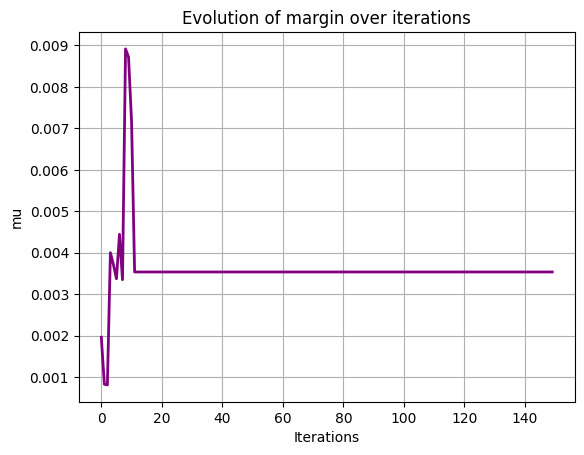

22:34:01 | INFO | machinemoo | Fit runtime: 11.37 seconds


In [18]:
# Test with gradient
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False
                               # gradient=True
                               )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

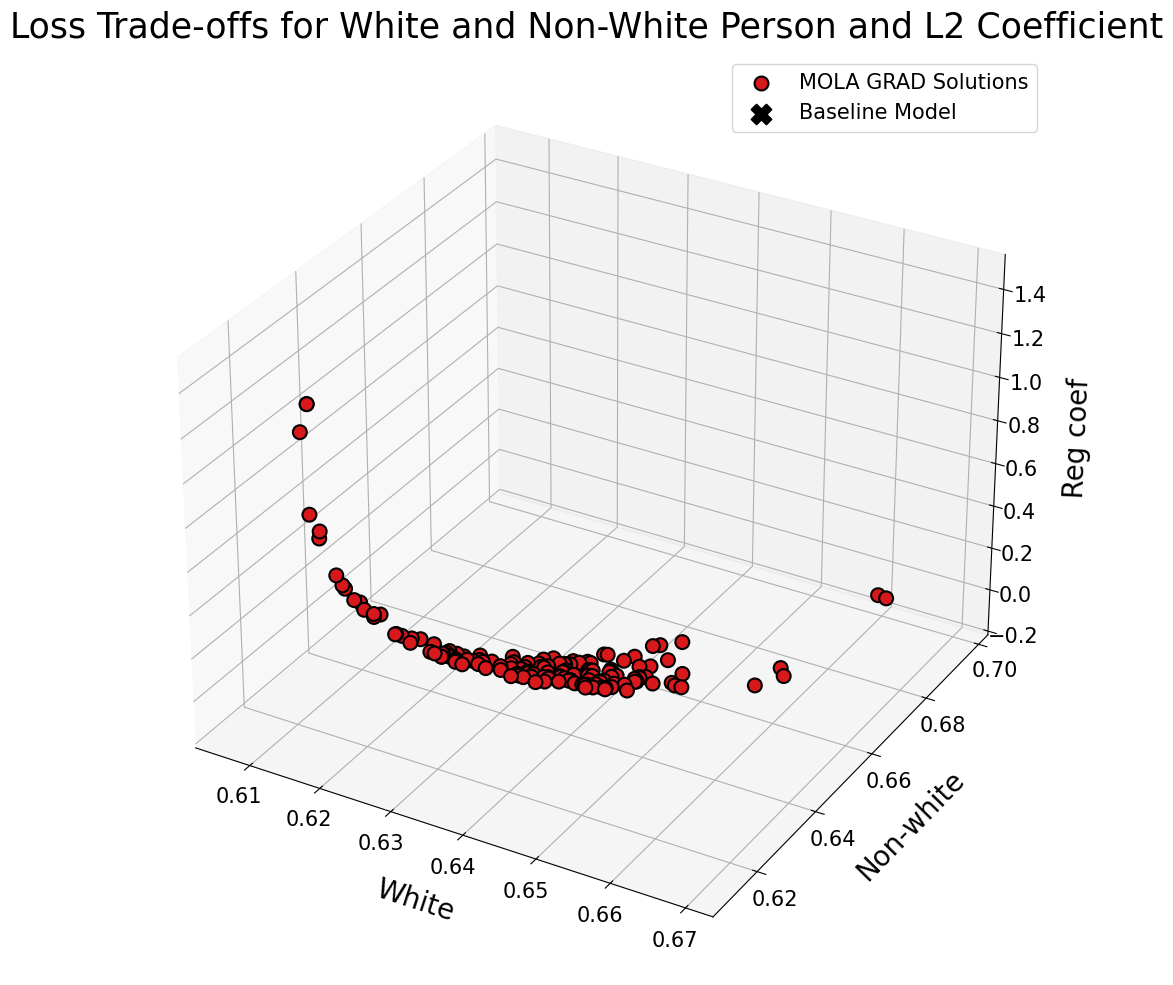

In [16]:
title = title="Loss Trade-offs for White and Non-White Person and L2 Coefficient"
plot_pareto(methods={'mola_grad': objs},
               labels=("White", "Non-White", "Reg Coef"), 
               title=title,
               point = equal.objs,
               save_path='images/3_objs_mola_grad.png',
               figsize=(10,10),
               fontsize=20,
               s_factor=2
               )

### MONISE

In [13]:
method = 'monise'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

22:31:28 | DEBUG | machinemoo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 150, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
22:31:28 | DEBUG | machinemoo | Finding 1th individual minima
22:31:28 | DEBUG | machinemoo | Finding 2th individual minima
22:31:28 | DEBUG | machinemoo | Finding 3th individual minima
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:452: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/workspace/machinem

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


22:31:29 | DEBUG | machinemoo | 11th solution - importance: 0.1286916108340204
22:31:29 | DEBUG | machinemoo | 12th solution - importance: 0.03331041147209454
22:31:29 | DEBUG | machinemoo | 13th solution - importance: 0.0328149984336095
22:31:29 | DEBUG | machinemoo | 14th solution - importance: 0.0315441557342531
22:31:29 | DEBUG | machinemoo | 15th solution - importance: 0.03094439018491531


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


22:31:29 | DEBUG | machinemoo | 16th solution - importance: 0.008356963588728386
22:31:29 | DEBUG | machinemoo | 17th solution - importance: 0.008326853609434312
22:31:29 | DEBUG | machinemoo | 18th solution - importance: 0.00829843869156949
22:31:29 | DEBUG | machinemoo | 19th solution - importance: 0.008253683163471111


...

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


22:31:30 | DEBUG | machinemoo | 33th solution - importance: 0.002286855221201558
22:31:30 | DEBUG | machinemoo | 34th solution - importance: 0.002286855221201558
22:31:30 | DEBUG | machinemoo | 35th solution - importance: 0.002286855221201558


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


22:31:30 | DEBUG | machinemoo | 36th solution - importance: 0.002286855221201558
22:31:30 | INFO | machinemoo | Best solution found.


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Ramdon Weighted Sum

In [14]:
method = 'random_weight'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

22:31:31 | WARNING | machinemoo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
22:31:31 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
22:31:31 | DEBUG | machinemoo | Finding 1th individual minima
22:31:31 | DEBUG | machinemoo | Finding 2th individual minima
22:31:31 | DEBUG | machinemoo | Finding 3th individual minima
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:452: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered 

22:31:31 | DEBUG | machinemoo | 4th solution
22:31:31 | DEBUG | machinemoo | 5th solution
22:31:31 | DEBUG | machinemoo | 6th solution
22:31:31 | DEBUG | machinemoo | 7th solution
22:31:31 | DEBUG | machinemoo | 8th solution
22:31:31 | DEBUG | machinemoo | 9th solution
22:31:31 | DEBUG | machinemoo | 10th solution
22:31:31 | DEBUG | machinemoo | 11th solution
22:31:31 | DEBUG | machinemoo | 12th solution
22:31:31 | DEBUG | machinemoo | 13th solution
22:31:31 | DEBUG | machinemoo | 14th solution
22:31:31 | DEBUG | machinemoo | 15th solution
22:31:31 | DEBUG | machinemoo | 16th solution
22:31:31 | DEBUG | machinemoo | 17th solution
22:31:31 | DEBUG | machinemoo | 18th solution
22:31:31 | DEBUG | machinemoo | 19th solution
22:31:31 | DEBUG | machinemoo | 20th solution
22:31:31 | DEBUG | machinemoo | 21th solution
22:31:31 | DEBUG | machinemoo | 22th solution
22:31:31 | DEBUG | machinemoo | 23th solution
22:31:31 | DEBUG | machinemoo | 24th solution
22:31:31 | DEBUG | machinemoo | 25th sol

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

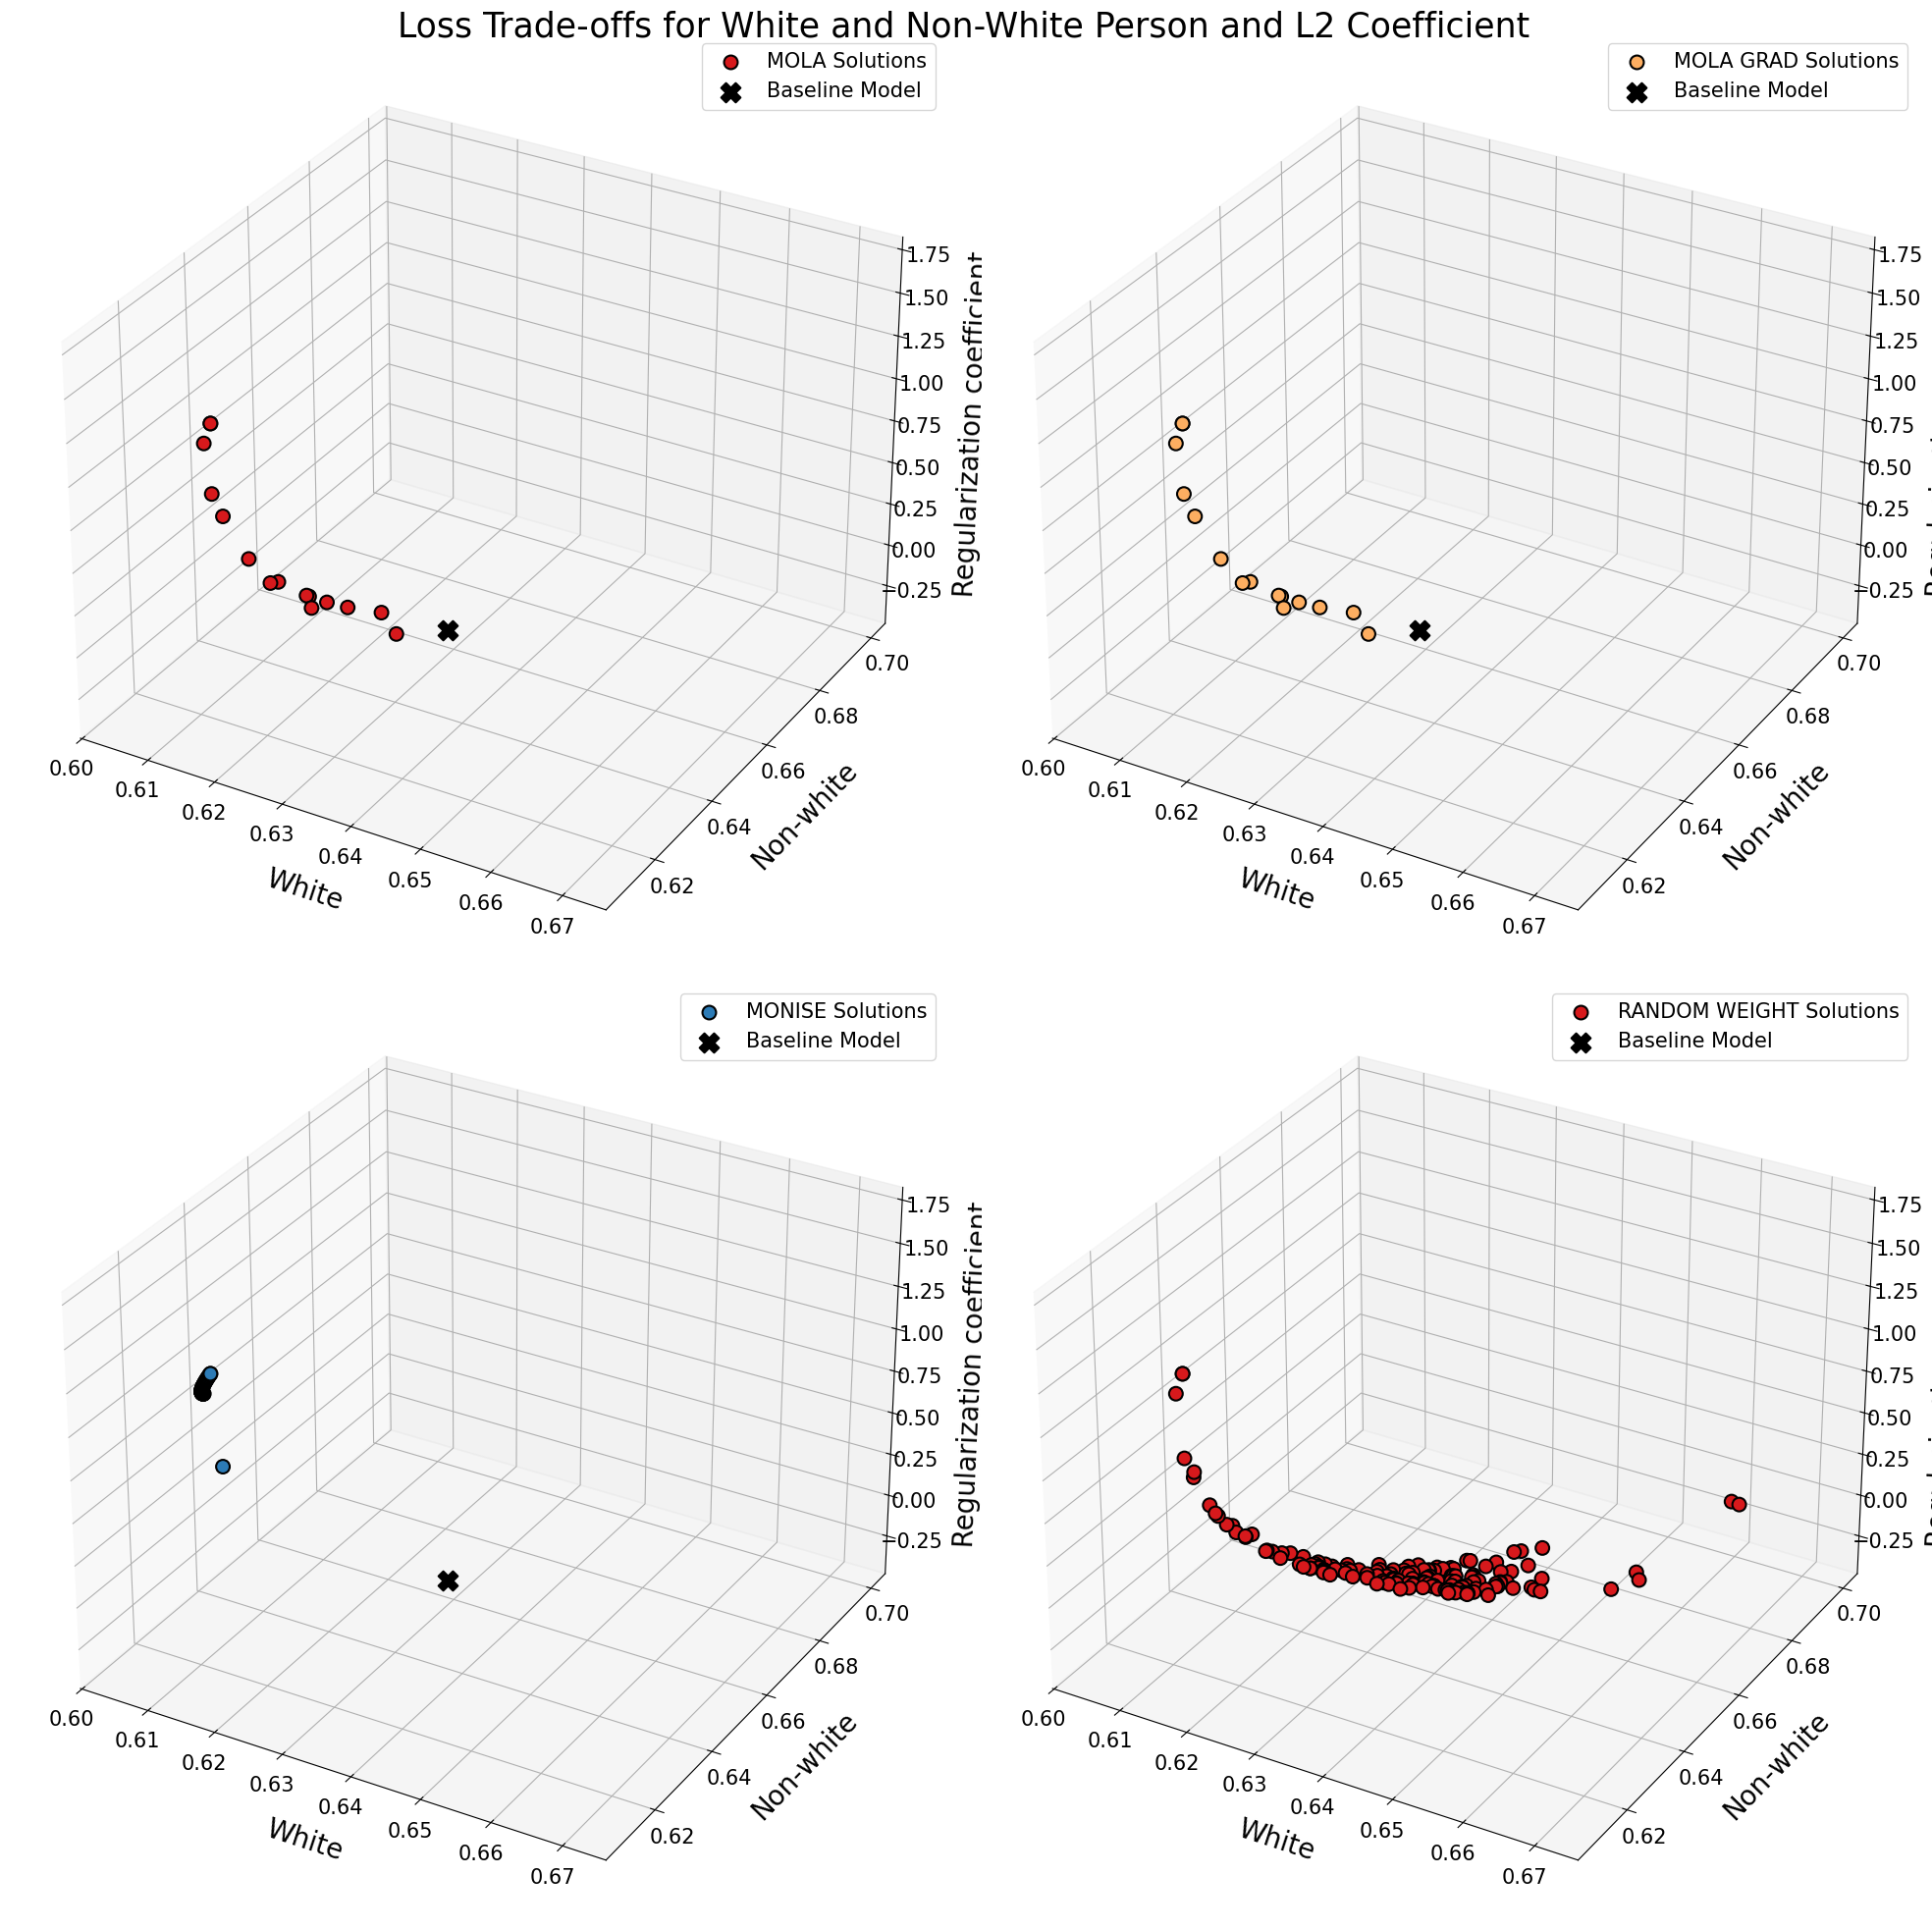

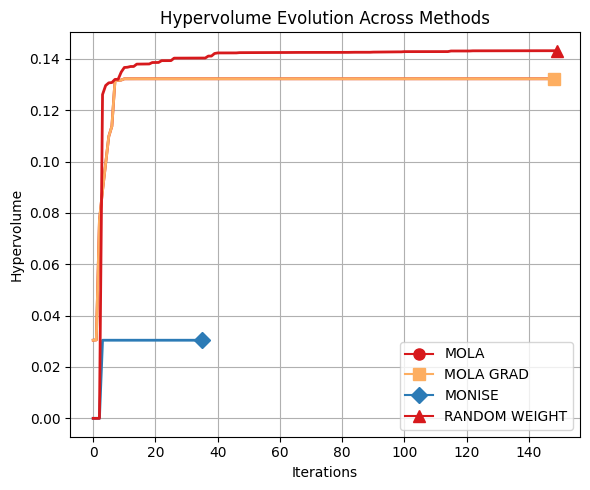

In [15]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

axes_label = ["White", "Non-White", "Regularization Coefficient"]

plot_pareto(methods=pareto_dict,
               labels=axes_label, 
               title=title,
               point = equal.objs,
               save_path='images/3_objs_methods.png',
               figsize=(10,10),
               fontsize=20,
               s_factor=2
               )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)